In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
df = pd.read_csv(
    "../data/IPL.csv",
    dtype={
        "review_batter": "string",
        "team_reviewed": "string",
        "review_decision": "string",
        "umpire": "string",
        "season": "string",
        "superover_winner": "string",
        "result_type": "string",
        "method": "string",
        "event_match_no": "string"
    }
)

In [3]:
df = df.drop(columns=["Unnamed: 0"])
df["date"] = pd.to_datetime(df["date"])

In [11]:
boundary_stats = (
    df.assign(
        is_four=df["runs_batter"].eq(4).astype(int),
        is_six=df["runs_batter"].eq(6).astype(int),
    )
    .groupby("batter", as_index=False)
    .agg(
        fours=("is_four", "sum"),
        sixes=("is_six", "sum"),
    )
)

boundary_stats["total_boundaries"] = boundary_stats["fours"] + boundary_stats["sixes"]

boundary_stats = boundary_stats.sort_values(
    by=["total_boundaries", "sixes", "fours"],
    ascending=False
).reset_index(drop=True)

boundary_stats.head(20)

,batter,fours,sixes,total_boundaries
0,V Kohli,774,292,1066
1,RG Sharma,640,303,943
2,S Dhawan,768,153,921
3,DA Warner,663,236,899
4,CH Gayle,408,359,767
5,SK Raina,506,204,710
6,AB de Villiers,414,253,667
7,RV Uthappa,481,182,663
8,KL Rahul,453,208,661
9,MS Dhoni,375,264,639


In [4]:
df[['innings','batting_team', 'bowling_team','over','ball','ball_no',
    'batter','bat_pos','runs_batter','bowler','valid_ball','runs_extras','runs_total']].head(40)

,innings,batting_team,bowling_team,over,ball,ball_no,batter,bat_pos,runs_batter,bowler,valid_ball,runs_extras,runs_total
0,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,0.1,SC Ganguly,1,0,P Kumar,1,1,1
1,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0.2,BB McCullum,2,0,P Kumar,1,0,0
2,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0.3,BB McCullum,2,0,P Kumar,0,1,1
3,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0.3,BB McCullum,2,0,P Kumar,1,0,0
4,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0.4,BB McCullum,2,0,P Kumar,1,0,0
5,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,0.5,BB McCullum,2,0,P Kumar,1,0,0
6,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,6,0.6,BB McCullum,2,0,P Kumar,1,1,1
7,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,1,1.1,BB McCullum,2,0,Z Khan,1,0,0
8,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,2,1.2,BB McCullum,2,4,Z Khan,1,0,4
9,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,3,1.3,BB McCullum,2,4,Z Khan,1,0,4


In [5]:
df.head(100)

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,132065,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,15,2,...,155,92,2,NaN,9,8,0,"('BB McCullum', 'DJ Hussey')",NaN,False
96,132066,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,15,3,...,157,93,2,NaN,101,53,0,"('BB McCullum', 'DJ Hussey')",NaN,False
97,132067,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,15,4,...,157,94,2,NaN,101,54,0,"('BB McCullum', 'DJ Hussey')",NaN,False
98,132068,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,15,5,...,158,95,2,NaN,102,55,0,"('BB McCullum', 'DJ Hussey')",NaN,False


In [ ]:
df.shape

(278205, 63)

In [4]:
match_columns = [
    'match_id',
    'date',
    'match_type',
    'event_name',
    'innings',
    'batting_team',
    'bowling_team',
    'match_won_by',
    'win_outcome',
    'toss_winner',
    'toss_decision',
    'venue',
    'city',
    'day',
    'month',
    'year',
    'season',
    'superover_winner',
    'event_match_no',
    'stage'  
]

match_df = df[match_columns].copy()
match_df['team_1'] = np.where(
    match_df['innings'] == 1,
    match_df['batting_team'],
    match_df['bowling_team']
)
match_df['team_2'] = np.where(
    match_df['innings'] == 1,
    match_df['bowling_team'],
    match_df['batting_team']
)
match_df = (
    match_df
    .drop_duplicates(subset="match_id")
    .reset_index(drop=True)
)
match_df = match_df.drop(
    columns=["batting_team", "bowling_team", "innings"],
    errors="ignore"
)

In [7]:
match_columns_new = [
    'match_id',
    'date',
    'match_type',
    'event_name',
    'team_1',
    'team_2',
    'match_won_by',
    'win_outcome',
    'toss_winner',
    'toss_decision',
    'venue',
    'city',
    'day',
    'month',
    'year',
    'season',
    'superover_winner',
    'event_match_no',
    'stage'  
]
match_df = match_df[match_columns_new]

In [ ]:
match_df.shape

(1169, 18)

In [ ]:
match_df["match_id"].nunique()

1169

In [8]:
match_df["match_id"].nunique() == len(match_df)

True

In [ ]:
match_df[].head(10)

,match_id,date,match_type,event_name,team_1,team_2,match_won_by,win_outcome,toss_winner,toss_decision,venue,city,day,month,year,season,superover_winner,event_match_no
0,335982,2008-04-18,T20,Indian Premier League,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,140 runs,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,18,4,2008,2007/08,<NA>,1
1,335983,2008-04-19,T20,Indian Premier League,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,33 runs,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",Chandigarh,19,4,2008,2007/08,<NA>,2
2,335984,2008-04-19,T20,Indian Premier League,Rajasthan Royals,Delhi Daredevils,Delhi Daredevils,9 wickets,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi,19,4,2008,2007/08,<NA>,3
3,335985,2008-04-20,T20,Indian Premier League,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,5 wickets,Mumbai Indians,bat,Wankhede Stadium,Mumbai,20,4,2008,2007/08,<NA>,5
4,335986,2008-04-20,T20,Indian Premier League,Deccan Chargers,Kolkata Knight Riders,Kolkata Knight Riders,5 wickets,Deccan Chargers,bat,Eden Gardens,Kolkata,20,4,2008,2007/08,<NA>,4
5,335987,2008-04-21,T20,Indian Premier League,Kings XI Punjab,Rajasthan Royals,Rajasthan Royals,6 wickets,Kings XI Punjab,bat,Sawai Mansingh Stadium,Jaipur,21,4,2008,2007/08,<NA>,6
6,335988,2008-04-22,T20,Indian Premier League,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,9 wickets,Deccan Chargers,bat,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,22,4,2008,2007/08,<NA>,7
7,335989,2008-04-23,T20,Indian Premier League,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,6 runs,Mumbai Indians,field,"MA Chidambaram Stadium, Chepauk",Chennai,23,4,2008,2007/08,<NA>,8
8,335990,2008-04-24,T20,Indian Premier League,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,3 wickets,Rajasthan Royals,field,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,24,4,2008,2007/08,<NA>,9
9,335991,2008-04-25,T20,Indian Premier League,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,66 runs,Mumbai Indians,field,"Punjab Cricket Association Stadium, Mohali",Chandigarh,25,4,2008,2007/08,<NA>,10


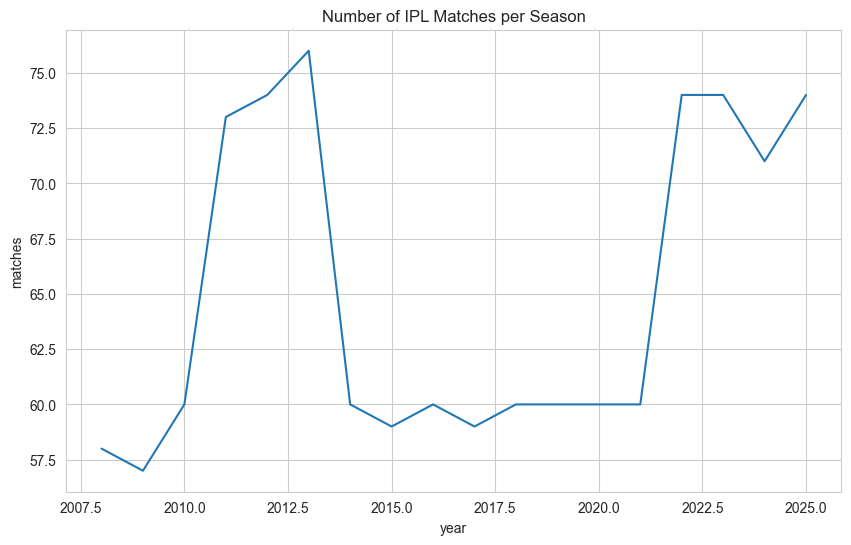

In [8]:
matches_per_year = (
    match_df
    .groupby("year")["match_id"]
    .count()
    .reset_index(name="matches")
)

sns.lineplot(data=matches_per_year, x="year", y="matches")
plt.title("Number of IPL Matches per Season")
plt.show()

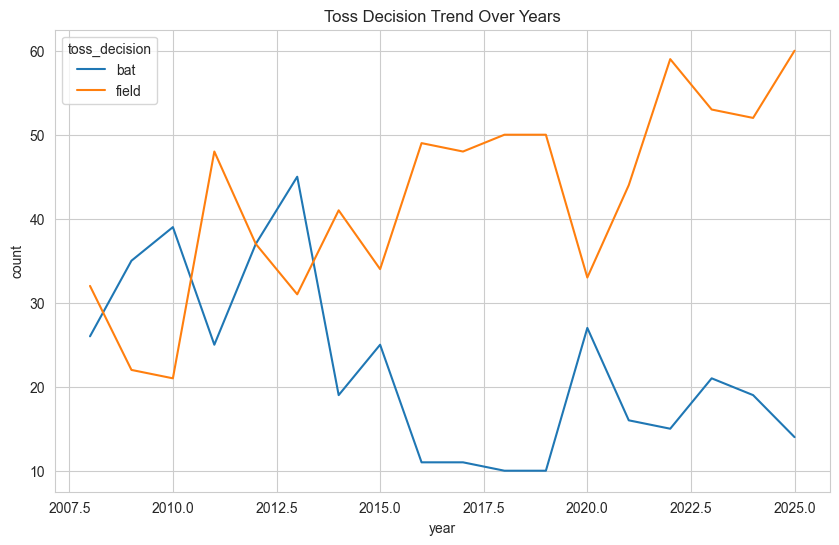

In [9]:
toss_trend = (
    match_df
    .groupby(["year", "toss_decision"])
    .size()
    .reset_index(name="count")
)

sns.lineplot(
    data=toss_trend,
    x="year",
    y="count",
    hue="toss_decision"
)

plt.title("Toss Decision Trend Over Years")
plt.show()

In [10]:
matches_per_year

,year,matches
0,2008,58
1,2009,57
2,2010,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59


In [11]:
match_df["toss_win_match_win"] = (
    match_df["toss_winner"] == match_df["match_won_by"]
)

toss_impact = (
    match_df["toss_win_match_win"]
    .value_counts(normalize=True) * 100
)

toss_impact

toss_win_match_win
True     50.556031
False    49.443969
Name: proportion, dtype: float64

In [12]:
match_df["team1_win"] = match_df["match_won_by"] == match_df["team_1"]

team1_win_pct = match_df["team1_win"].mean() * 100
team2_win_pct = 100 - team1_win_pct

team1_win_pct, team2_win_pct

(np.float64(44.91017964071856), np.float64(55.08982035928144))

In [13]:
matches_per_venue_year = (
    match_df
    .groupby(["year", "venue"])["match_id"]
    .count()
    .reset_index(name="matches")
)

matches_per_venue_year = matches_per_venue_year.sort_values(
    by=['year','matches','venue'],
    ascending=[True,False,True]
)

matches_per_venue_year

,year,venue,matches
1,2008,Eden Gardens,7
3,2008,M Chinnaswamy Stadium,7
4,2008,"MA Chidambaram Stadium, Chepauk",7
5,2008,"Punjab Cricket Association Stadium, Mohali",7
6,2008,"Rajiv Gandhi International Stadium, Uppal",7
...,...,...,...
183,2025,Maharaja Yadavindra Singh International Cricke...,5
176,2025,"Barsapara Cricket Stadium, Guwahati",2
178,2025,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,2
180,2025,"Himachal Pradesh Cricket Association Stadium, ...",2


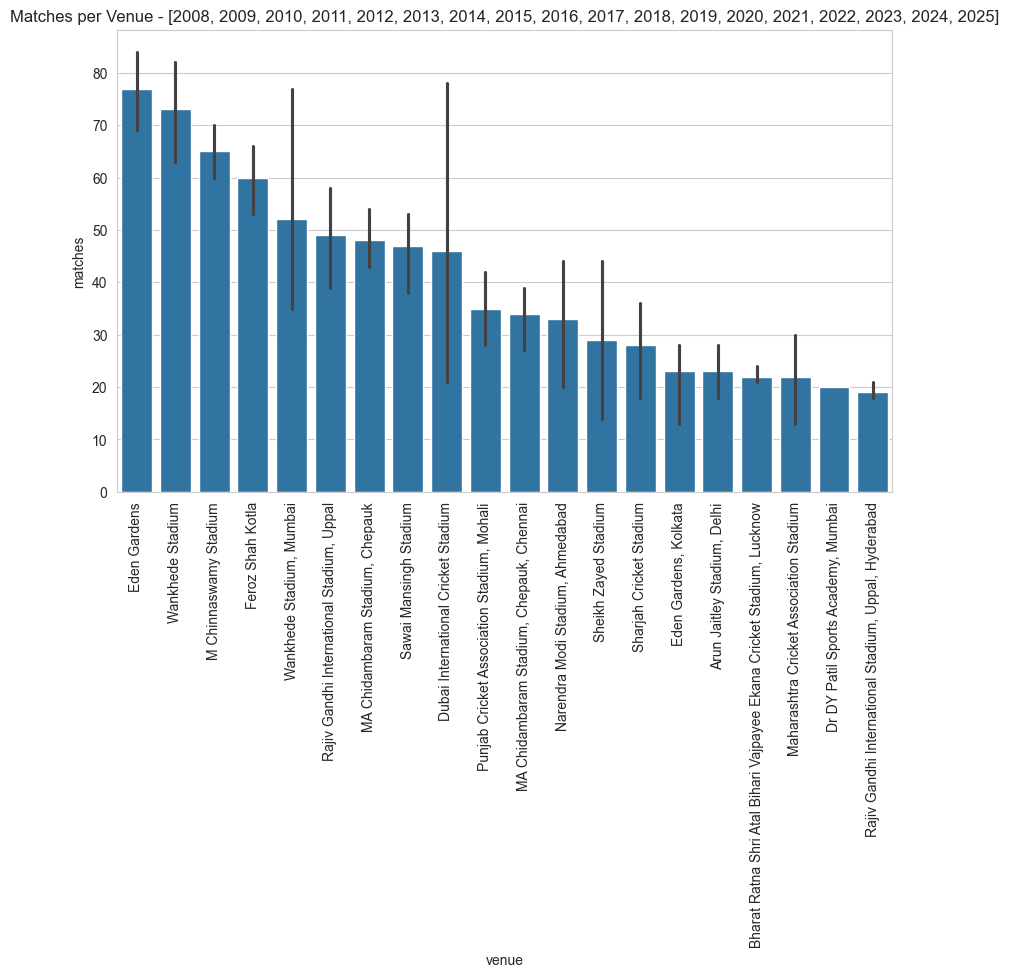

In [14]:
years_selected = [2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]

plot_df = matches_per_venue_year[
    matches_per_venue_year["year"].isin(years_selected)
]

venue_order = (
    plot_df
    .groupby("venue")["matches"]
    .sum()
    .sort_values(ascending=False)
    .nlargest(20)
    .index
)

sns.barplot(
    data=plot_df,
    x="venue",
    y="matches",
    order=venue_order,
    estimator=sum
)

plt.xticks(rotation=90)
plt.title(f"Matches per Venue - {years_selected}")
plt.show()

In [11]:
sorted_venues = sorted(match_df["venue"].unique())
sorted_venues

['Arun Jaitley Stadium',
 'Arun Jaitley Stadium, Delhi',
 'Barabati Stadium',
 'Barsapara Cricket Stadium, Guwahati',
 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow',
 'Brabourne Stadium',
 'Brabourne Stadium, Mumbai',
 'Buffalo Park',
 'De Beers Diamond Oval',
 'Dr DY Patil Sports Academy',
 'Dr DY Patil Sports Academy, Mumbai',
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam',
 'Dubai International Cricket Stadium',
 'Eden Gardens',
 'Eden Gardens, Kolkata',
 'Feroz Shah Kotla',
 'Green Park',
 'Himachal Pradesh Cricket Association Stadium',
 'Himachal Pradesh Cricket Association Stadium, Dharamsala',
 'Holkar Cricket Stadium',
 'JSCA International Stadium Complex',
 'Kingsmead',
 'M Chinnaswamy Stadium',
 'M Chinnaswamy Stadium, Bengaluru',
 'M.Chinnaswamy Stadium',
 'MA Chidambaram Stadium',
 'MA Chidambaram Stadium, Chepauk',
 'MA Chidambaram Stadium, Chepauk, Chennai',
 'Maharaja

In [14]:
venue_city = (
    match_df[["venue", "city"]]
    .dropna()
    .drop_duplicates()
    .sort_values("venue")
)

venue_city_list = list(
    venue_city.itertuples(index=False, name=None)
)

venue_city_list

[('Arun Jaitley Stadium', 'Delhi'),
 ('Arun Jaitley Stadium, Delhi', 'Delhi'),
 ('Barabati Stadium', 'Cuttack'),
 ('Barsapara Cricket Stadium, Guwahati', 'Guwahati'),
 ('Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow',
  'Lucknow'),
 ('Brabourne Stadium', 'Mumbai'),
 ('Brabourne Stadium, Mumbai', 'Mumbai'),
 ('Buffalo Park', 'East London'),
 ('De Beers Diamond Oval', 'Kimberley'),
 ('Dr DY Patil Sports Academy', 'Mumbai'),
 ('Dr DY Patil Sports Academy, Mumbai', 'Mumbai'),
 ('Dr DY Patil Sports Academy, Mumbai', 'Navi Mumbai'),
 ('Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium', 'Visakhapatnam'),
 ('Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam',
  'Visakhapatnam'),
 ('Dubai International Cricket Stadium', 'Dubai'),
 ('Dubai International Cricket Stadium', 'Unknown'),
 ('Eden Gardens', 'Kolkata'),
 ('Eden Gardens, Kolkata', 'Kolkata'),
 ('Feroz Shah Kotla', 'Delhi'),
 ('Green Park', 'Kanpur'),
 ('Himachal Pradesh Cricket Association Stad

In [18]:
fielders_list = (
    df["fielders"]
    .dropna()
    .unique()
)

fielders_list

array(['JH Kallis', 'P Kumar', 'CL White', ..., "W O'Rourke",
       'Urvil Patel', 'BKG Mendis'], shape=(1101,), dtype=object)

In [20]:
batters_list = (
    df["batter"]
    .dropna()
    .unique()
)

batters_list

array(['SC Ganguly', 'BB McCullum', 'RT Ponting', 'DJ Hussey',
       'Mohammad Hafeez', 'R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis',
       'CL White', 'MV Boucher', 'B Akhil', 'AA Noffke', 'P Kumar',
       'Z Khan', 'SB Joshi', 'PA Patel', 'ML Hayden', 'MEK Hussey',
       'MS Dhoni', 'SK Raina', 'JDP Oram', 'S Badrinath', 'K Goel',
       'JR Hopes', 'KC Sangakkara', 'Yuvraj Singh', 'SM Katich',
       'IK Pathan', 'T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif',
       'DS Lehmann', 'RA Jadeja', 'M Rawat', 'D Salunkhe', 'SK Warne',
       'SK Trivedi', 'G Gambhir', 'V Sehwag', 'S Dhawan', 'L Ronchi',
       'ST Jayasuriya', 'DJ Thornely', 'RV Uthappa', 'PR Shah',
       'AM Nayar', 'SM Pollock', 'Harbhajan Singh', 'S Chanderpaul',
       'LRPL Taylor', 'AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxman',
       'A Symonds', 'RG Sharma', 'SB Styris', 'AS Yadav', 'SB Bangar',
       'WPUJC Vaas', 'RP Singh', 'WP Saha', 'LR Shukla',
       'DPMD Jayawardene', 'S Sohal', 'B Lee', 'PP Cha

In [22]:
runs_list = (
    df.loc[df["runs_not_boundary"],
           ["runs_extras", "runs_total", "runs_bowler", "runs_not_boundary"]]
)

runs_list

,runs_extras,runs_total,runs_bowler,runs_not_boundary
7415,0,6,6,True
23804,0,4,4,True
47910,0,4,4,True
54289,0,4,4,True
55278,0,4,4,True
59173,0,6,6,True
75071,0,6,6,True
82902,0,4,4,True
91949,0,6,6,True
123593,0,6,6,True


In [9]:
stage_list = (
    df["stage"]
    .dropna()
    .unique()
)

stage_list

array(['Unknown', 'Semi Final', 'Final', '3rd Place Play-Off',
       'Qualifier 1', 'Elimination Final', 'Qualifier 2', 'Eliminator'],
      dtype=object)